<a href="https://colab.research.google.com/github/shubham-bhk/Seasonal-Agriculture-Performance-Analysis-/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis

# **Major Data Analytics Project**

**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Project Goal:**
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.



# 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another. However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions. The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

### 2. Project Objectives

* Understand the structure and quality of the agricultural dataset.

* Clean and prepare the data for analysis.

* Explore seasonal patterns in the dataset.

* Perform descriptive and statistical analysis.

* Investigate relationships among relevant variables.

* Compare agricultural performance across seasons and other meaningful groups.

* Use appropriate univariate, bivariate and multivariate visualizations.

* Identify significant findings from the data.

* Develop evidence-based insights and recommendations.


# 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

Dataset file: seasonal_agriculture_performance_dataset.csv

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Display floating-point numbers with 2 decimal places
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset

file_path = "/content/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


# 4. Initial Data Understanding

In [3]:
# Number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [4]:
# View the first 5 rows

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [5]:
# View the bottom 5 rows

df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [6]:
# Random sample of records

df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.70,26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [7]:
# Display all column names

print("Column names:")

for i, col in enumerate(df.columns, start=1):
    print(i, ":", col)

Column names:
1 : Farm_ID
2 : State
3 : District
4 : Crop
5 : Season
6 : Farm_Area_Hectares
7 : Rainfall_mm
8 : Avg_Temperature_C
9 : Humidity_pct
10 : Sunlight_Hours_Day
11 : Soil_pH
12 : Soil_Moisture_pct
13 : Nitrogen_kg_ha
14 : Phosphorus_kg_ha
15 : Potassium_kg_ha
16 : Irrigation_Method
17 : Fertilizer_kg_ha
18 : Pesticide_Litre_ha
19 : Seed_Quality_Score
20 : Yield_Tonnes_Ha
21 : Production_Tonnes
22 : Market_Price_INR_Tonne
23 : Total_Cost_INR
24 : Revenue_INR
25 : Profit_INR
26 : Water_Used_m3
27 : Water_Efficiency_t_per_1000m3
28 : Disease_Pest_Risk_pct


In [8]:
# data types of all columns

df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [9]:
# Data types and non-null Counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [10]:
# Statistical summary of numerical columns

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [11]:
# Check unique values

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


Farm_ID
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

State
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [12]:
# Check missing values

missing_values = df.isnull().sum()

print(missing_values)

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [13]:
# columns with missing values

missing_values[missing_values > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [14]:
# duplicate rows count

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [15]:
# Basic dataset summary

print("===== DATASET SUMMARY =====")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Numerical columns:", len(df.select_dtypes(include=np.number).columns))
print("Categorical columns:", len(df.select_dtypes(include="object").columns))
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

===== DATASET SUMMARY =====
Rows: 4000
Columns: 28
Numerical columns: 22
Categorical columns: 6
Missing values: 120
Duplicate rows: 0



# 5. Data Cleaning and Preprocessing

Data cleaning is an important step before performing analysis because missing or inconsistent values can affect the accuracy of statistical calculations and visualizations.

First, we calculate the percentage of missing values in each column to understand the extent of missing data.

In [16]:
# Calculate the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Display only columns with missing values
missing_percentage[missing_percentage > 0]

,0
Rainfall_mm,1.20
Soil_Moisture_pct,1.00
Yield_Tonnes_Ha,0.80


# 6. Handling Missing Values

The missing values are present in numerical columns: Rainfall_mm, Soil_Moisture_pct, and Yield_Tonnes_Ha.

Since these variables are numerical and the percentage of missing values is relatively small, median imputation is used to fill the missing values. The median is preferred because it is less affected by extreme values than the mean.

In [17]:
# Fill missing values using the median of each respective column

df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

In [18]:
# Verify that all missing values have been handled
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


# 7. Identifying Data Types

The dataset contains both categorical and numerical variables. Identifying these variables is important because different types of variables require different analytical and visualization techniques.

Categorical variables represent groups or categories, while numerical variables contain measurable quantities.

In [19]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method'], dtype='object')

In [20]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C',
       'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct',
       'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [21]:
# Count categorical and numerical columns
print("Number of categorical columns:", len(categorical_columns))
print("Number of numerical columns:", len(numerical_columns))

Number of categorical columns: 6
Number of numerical columns: 22


In [22]:
# Count the number of records in each season
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


# 8. Season-wise Record Distribution

Understanding the distribution of records across seasons is important before performing seasonal comparisons. It helps us determine how many observations are available for each season and whether the dataset is evenly distributed across seasons.

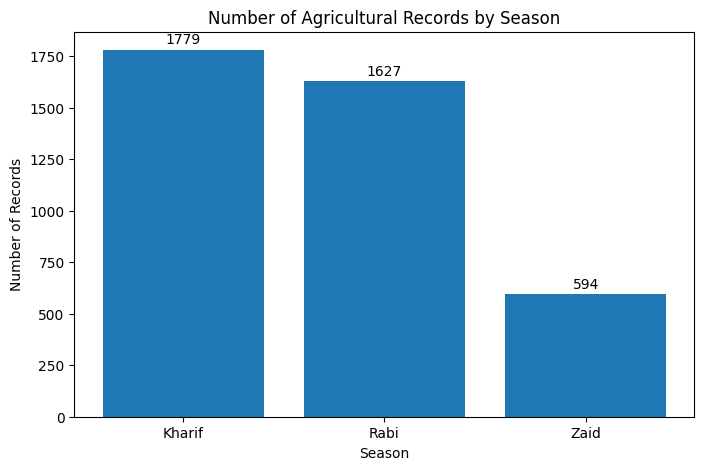

In [23]:
# Count the number of records in each season
season_counts = df['Season'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 5))
plt.bar(season_counts.index, season_counts.values)

# Add title and labels
plt.title('Number of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')

# Display the values on top of each bar
for i, value in enumerate(season_counts.values):
    plt.text(i, value + 30, str(value), ha='center')

plt.show()

# Interpretation

The bar chart shows that Kharif has the highest number of observations with 1,779 records, followed by Rabi with 1,627 records. Zaid has the lowest number of observations with 594 records.

This indicates that the dataset is not evenly distributed across seasons. Therefore, seasonal comparisons should consider the difference in the number of observations across seasons.

# 9. Season-wise Average Yield Analysis

Yield is an important indicator of agricultural performance. In this analysis, the average yield is compared across different seasons to understand whether agricultural productivity varies with seasonal conditions.

The mean yield is used to obtain the overall average yield for each season.

In [24]:
# Calculate average yield for each season
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

season_yield

,Yield_Tonnes_Ha
Season,
Kharif,5.63
Rabi,5.04
Zaid,4.64


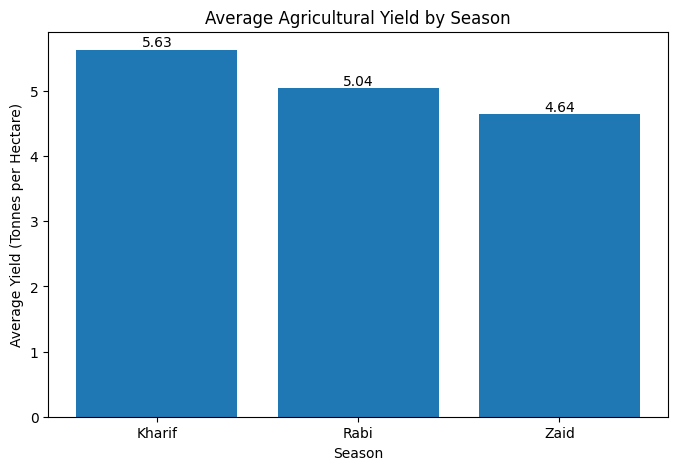

In [25]:
# Create a bar chart of average yield by season
plt.figure(figsize=(8, 5))

plt.bar(season_yield.index, season_yield.values)

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes per Hectare)')

# Display values on top of bars
for i, value in enumerate(season_yield.values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center')

plt.show()

# Interpretation

The analysis shows that Kharif has the highest average agricultural yield at 5.63 tonnes per hectare. Rabi has an average yield of 5.04 tonnes per hectare, while Zaid has the lowest average yield at 4.64 tonnes per hectare.

This indicates that agricultural productivity varies across seasons. The average yield in Kharif is higher than Rabi and Zaid, while Zaid shows the lowest average yield among the three seasons.

Therefore, season appears to be an important factor associated with differences in agricultural yield in this dataset. However, further analysis of environmental conditions, farming practices, resource usage, and other factors is required to understand the reasons behind these differences.

# 10. Season-wise Average Production Analysis

Production is another important measure of agricultural performance. While yield represents productivity per hectare, total production represents the overall quantity of agricultural output.

In this analysis, the average production is compared across different seasons to identify seasonal differences in agricultural output.

In [26]:
# Calculate average production for each season
season_production = df.groupby('Season')['Production_Tonnes'].mean()

season_production

,Production_Tonnes
Season,
Kharif,46.31
Rabi,41.49
Zaid,38.89


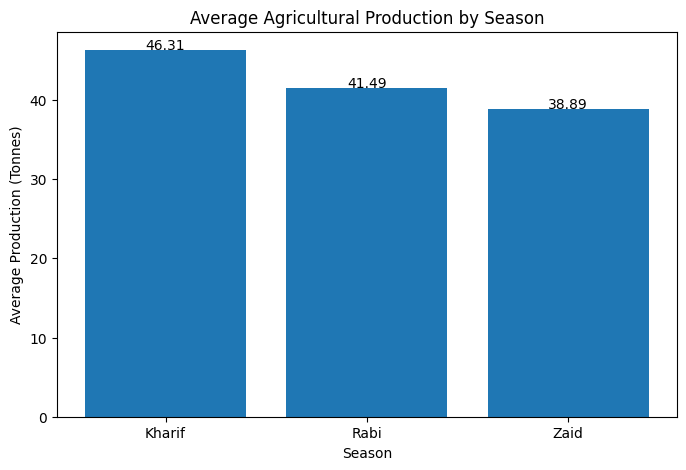

In [27]:
# Create a bar chart of average production by season
plt.figure(figsize=(8, 5))

plt.bar(season_production.index, season_production.values)

plt.title('Average Agricultural Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')

# Display values on top of bars
for i, value in enumerate(season_production.values):
    plt.text(i, value + 0.1, f'{value:.2f}', ha='center')

plt.show()

# Interpretation

The analysis shows that Kharif has the highest average agricultural production at 46.31 tonnes, followed by Rabi at 41.49 tonnes. Zaid has the lowest average production at 38.89 tonnes.

This indicates that agricultural output varies across seasons, with Kharif showing the highest average production and Zaid showing the lowest. This pattern is consistent with the earlier yield analysis, where Kharif also recorded the highest average yield.

However, average production can also be influenced by factors such as farm area, environmental conditions, and farming practices. Therefore, further analysis is required to understand the factors associated with these seasonal differences.

# 11. Season-wise Average Profit Analysis

Agricultural performance is not limited to production and yield; economic performance is also an important aspect of agricultural activities.

In this analysis, the average profit is compared across different seasons to determine whether economic outcomes vary with seasonal conditions.

In [28]:
# Calculate average profit for each season
season_profit = df.groupby('Season')['Profit_INR'].mean()

season_profit

,Profit_INR
Season,
Kharif,178914.65
Rabi,87689.47
Zaid,-24804.82


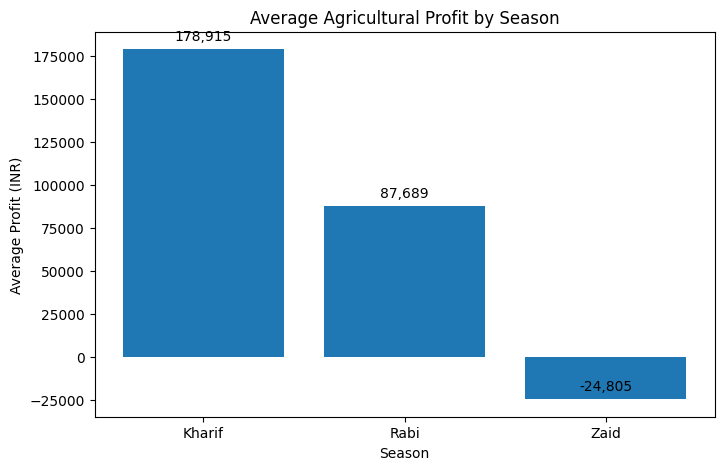

In [29]:
# Create a bar chart of average profit by season
plt.figure(figsize=(8, 5))

plt.bar(season_profit.index, season_profit.values)

plt.title('Average Agricultural Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

# Display values on top of bars
for i, value in enumerate(season_profit.values):
    plt.text(i, value + 5000, f'{value:,.0f}', ha='center')

plt.show()

# Interpretation

The analysis shows a significant difference in average profit across the three seasons. Kharif has the highest average profit of approximately ₹178,915, followed by Rabi with an average profit of approximately ₹87,689.

In contrast, Zaid has a negative average profit of approximately ₹24,805, indicating that the average agricultural activities in this season resulted in a loss rather than a profit.

This finding suggests that seasonal conditions may have a substantial association with agricultural economic performance. Although Kharif showed the highest average yield and production in the previous analyses, it also generated the highest average profit. Zaid, despite having agricultural production, resulted in an average loss.

Further analysis of total cost, revenue, resource usage, and environmental conditions is required to understand the possible factors behind these seasonal differences.

# 12. Season-wise Average Cost and Revenue Analysis

Profit is influenced by the relationship between revenue and total cost. Therefore, comparing average revenue and average cost across seasons can help us understand the economic differences observed in the previous analysis.

In this analysis, the average total cost and average revenue are compared across different seasons.

In [30]:
# Calculate average cost and revenue for each season
season_economic = df.groupby('Season')[['Total_Cost_INR', 'Revenue_INR']].mean()

season_economic

,Total_Cost_INR,Revenue_INR
Season,,
Kharif,531804.41,710719.06
Rabi,513836.58,601526.05
Zaid,543976.73,519171.90


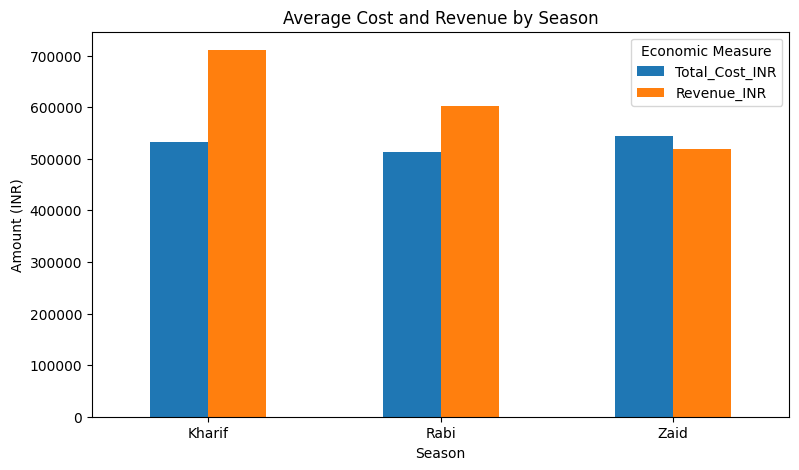

In [31]:
# Create a grouped bar chart for average cost and revenue
season_economic.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Average Cost and Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.legend(title='Economic Measure')

plt.show()

# Interpretation

The analysis shows that Kharif has the highest average revenue of approximately ₹710,710, while its average cost is approximately ₹531,804. This results in a positive difference between revenue and cost.

Rabi also has a positive difference between average revenue and average cost, with average revenue of approximately ₹601,526 and average cost of approximately ₹513,836.

In contrast, Zaid has an average cost of approximately ₹543,977, which is higher than its average revenue of approximately ₹519,172. This helps explain the negative average profit observed for the Zaid season in the previous analysis.

Overall, the comparison indicates that the relationship between revenue and cost is an important factor associated with seasonal differences in agricultural profitability.

# 13. Relationship Between Rainfall and Agricultural Yield

Rainfall is an important environmental condition that may be associated with agricultural productivity. In this analysis, rainfall is compared with agricultural yield to investigate whether a relationship or pattern exists between the two variables.

A scatter plot is used because both rainfall and yield are numerical variables and the plot allows us to observe their relationship across individual observations.

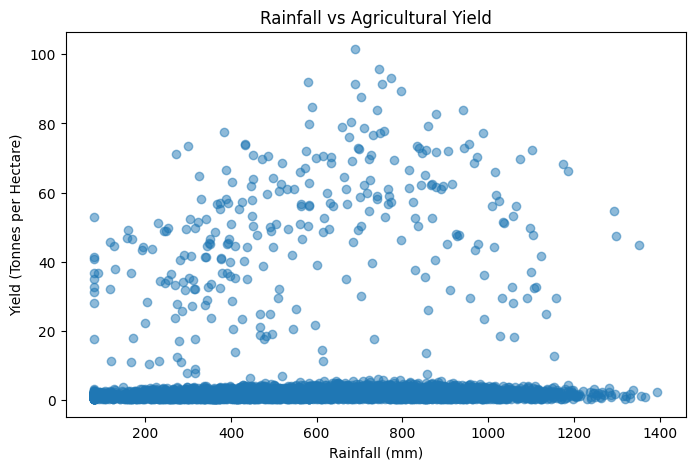

In [32]:
# Create a scatter plot of rainfall and yield
plt.figure(figsize=(8, 5))

plt.scatter(df['Rainfall_mm'], df['Yield_Tonnes_Ha'], alpha=0.5)

plt.title('Rainfall vs Agricultural Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.show()

In [33]:
# Calculate the correlation between rainfall and yield
rainfall_yield_corr = df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Rainfall and Yield:", rainfall_yield_corr)

Correlation between Rainfall and Yield: 0.030950993551650874


# Interpretation

The scatter plot shows a wide variation in agricultural yield across different rainfall levels. The observations do not form a strong linear pattern.

The correlation coefficient between rainfall and yield is approximately 0.031, indicating a very weak positive linear relationship between the two variables.

Therefore, rainfall alone does not appear to have a strong linear association with agricultural yield in this dataset. Other factors such as temperature, soil conditions, irrigation, fertilizer usage, seed quality, and farming practices may also be associated with variations in yield.

It is important to note that correlation does not imply causation, so this analysis does not establish that rainfall directly causes changes in agricultural yield.

# 14. Relationship Between Temperature and Agricultural Yield

Temperature is another important environmental condition that may be associated with agricultural productivity. In this analysis, average temperature is compared with agricultural yield to investigate whether a relationship exists between the two variables.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

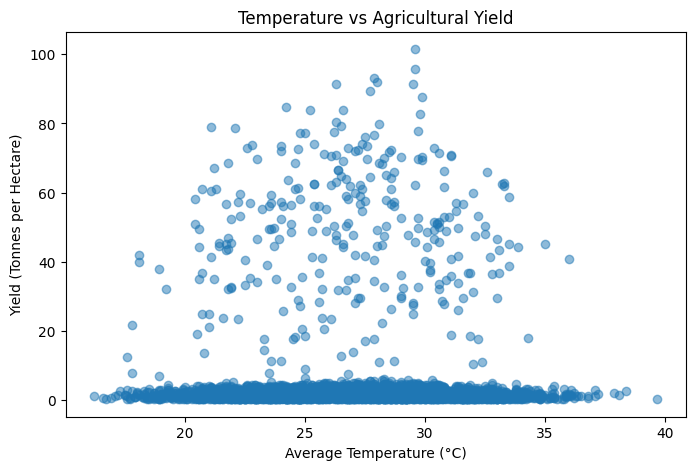

In [34]:
# Create a scatter plot of temperature and yield
plt.figure(figsize=(8, 5))

plt.scatter(df['Avg_Temperature_C'], df['Yield_Tonnes_Ha'], alpha=0.5)

plt.title('Temperature vs Agricultural Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.show()

In [35]:
# Calculate the correlation between temperature and yield
temperature_yield_corr = df['Avg_Temperature_C'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Temperature and Yield:", temperature_yield_corr)

Correlation between Temperature and Yield: 0.009996320546703593


# Interpretation

The scatter plot shows a wide variation in agricultural yield across different temperature levels. The observations do not form a clear linear pattern.

The correlation coefficient between average temperature and yield is approximately 0.01, indicating an almost negligible positive linear relationship between the two variables.

Therefore, average temperature alone does not appear to have a strong linear association with agricultural yield in this dataset. Other factors, such as rainfall, soil conditions, irrigation, fertilizer usage, seed quality, and farming practices, may also be associated with variations in yield.

It is important to note that correlation does not imply causation. This analysis only describes the observed linear relationship between temperature and yield in the available data.

# 15. Relationship Between Humidity and Agricultural Yield

Humidity is an important environmental condition that may influence agricultural performance. In this analysis, humidity is compared with agricultural yield to investigate whether a relationship or pattern exists between the two variables.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

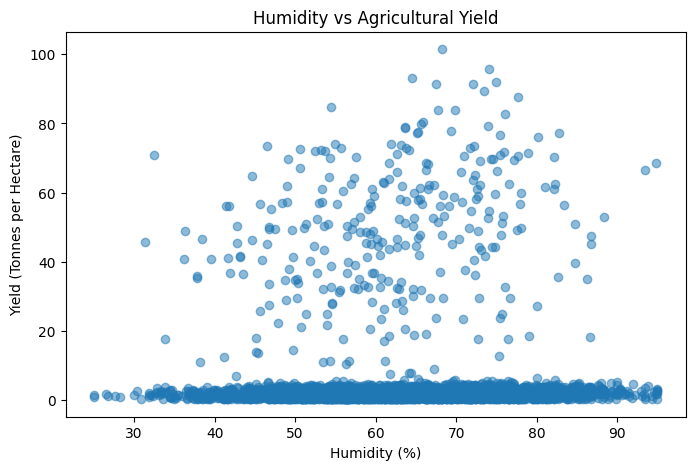

In [36]:
# Create a scatter plot of humidity and yield
plt.figure(figsize=(8, 5))

plt.scatter(df['Humidity_pct'], df['Yield_Tonnes_Ha'], alpha=0.5)

plt.title('Humidity vs Agricultural Yield')
plt.xlabel('Humidity (%)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.show()

In [37]:
# Calculate the correlation between humidity and yield
humidity_yield_corr = df['Humidity_pct'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Humidity and Yield:", humidity_yield_corr)

Correlation between Humidity and Yield: 0.012297441843645498


# Interpretation

The scatter plot shows considerable variation in agricultural yield across different humidity levels. The observations do not form a clear linear pattern.

The correlation coefficient between humidity and agricultural yield is approximately 0.012, indicating an almost negligible positive linear relationship between the two variables.

Therefore, humidity alone does not appear to have a strong linear association with agricultural yield in this dataset. Other factors such as soil conditions, irrigation, fertilizer usage, seed quality, and farming practices may also be associated with variations in yield.

It is important to note that correlation does not imply causation. This analysis only describes the observed linear relationship between humidity and yield in the available dataset.

# 16. Comparison of Environmental Factors and Yield

The relationships between rainfall, temperature, humidity, and agricultural yield were analyzed individually. In this step, their correlation coefficients are compared to identify which environmental factor has the strongest linear association with yield.

This comparison provides a concise summary of the environmental factors examined in the previous analyses.

In [38]:
# Compare correlations of environmental factors with yield

environmental_correlations = pd.Series({
    'Rainfall': df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha']),
    'Temperature': df['Avg_Temperature_C'].corr(df['Yield_Tonnes_Ha']),
    'Humidity': df['Humidity_pct'].corr(df['Yield_Tonnes_Ha'])
})

environmental_correlations

,0
Rainfall,0.03
Temperature,0.01
Humidity,0.01


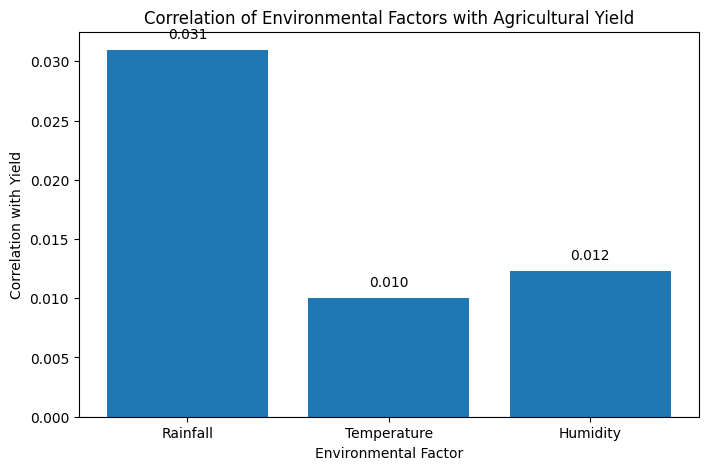

In [39]:
# Create a bar chart of environmental factor correlations

plt.figure(figsize=(8, 5))

plt.bar(
    environmental_correlations.index,
    environmental_correlations.values
)

plt.title('Correlation of Environmental Factors with Agricultural Yield')
plt.xlabel('Environmental Factor')
plt.ylabel('Correlation with Yield')

# Display correlation values
for i, value in enumerate(environmental_correlations.values):
    plt.text(i, value + 0.001, f'{value:.3f}', ha='center')

plt.axhline(0, linewidth=0.8)
plt.show()

# Interpretation

The comparison shows that rainfall has the strongest linear association with agricultural yield among the three environmental factors, with a correlation coefficient of approximately 0.031.

Humidity has a correlation of approximately 0.012, while temperature has a correlation of approximately 0.010 with yield.

Although rainfall has the highest correlation among the three factors, all three correlation values are very close to zero. This indicates that none of these individual environmental factors has a strong linear association with agricultural yield in the dataset.

Therefore, agricultural yield is likely associated with multiple factors rather than being strongly explained by rainfall, temperature, or humidity individually. Further analysis of soil conditions, irrigation, fertilizer usage, seed quality, and other farming-related variables can provide additional insights.

# 17. Season-wise Average Water Usage Analysis

Water is an important agricultural resource, and its usage may vary across different seasons. In this analysis, the average water used by farms is compared across seasons to identify differences in seasonal resource consumption.

In [40]:
# Calculate average water usage for each season
season_water = df.groupby('Season')['Water_Used_m3'].mean()

season_water

,Water_Used_m3
Season,
Kharif,6102.20
Rabi,5846.99
Zaid,6419.89


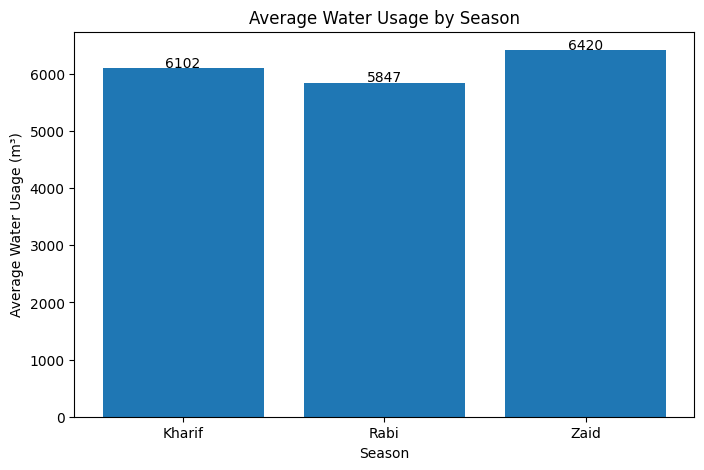

In [41]:
# Create a bar chart of average water usage by season
plt.figure(figsize=(8, 5))

plt.bar(season_water.index, season_water.values)

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Average Water Usage (m³)')

# Display values on top of bars
for i, value in enumerate(season_water.values):
    plt.text(i, value + 20, f'{value:.0f}', ha='center')

plt.show()

# Interpretation

The analysis shows that Zaid has the highest average water usage at approximately 6,420 m³, followed by Kharif at approximately 6,102 m³. Rabi has the lowest average water usage at approximately 5,847 m³.

An important observation is that Zaid has the highest average water usage even though it recorded the lowest average yield and a negative average profit in the previous analyses.

This suggests that higher water usage does not necessarily correspond to higher agricultural productivity or profitability in this dataset. Further analysis of water efficiency is therefore required to better understand the relationship between water consumption and agricultural performance.

# 18. Season-wise Water Efficiency Analysis

Water usage alone does not indicate how efficiently water resources are being utilized. Therefore, water efficiency is analyzed across seasons to determine how effectively agricultural output is associated with water consumption.

This analysis helps provide a more meaningful comparison of seasonal water resource utilization.

In [42]:
# Calculate average water efficiency for each season
season_water_efficiency = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean()

season_water_efficiency

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.89
Rabi,5.19
Zaid,4.41


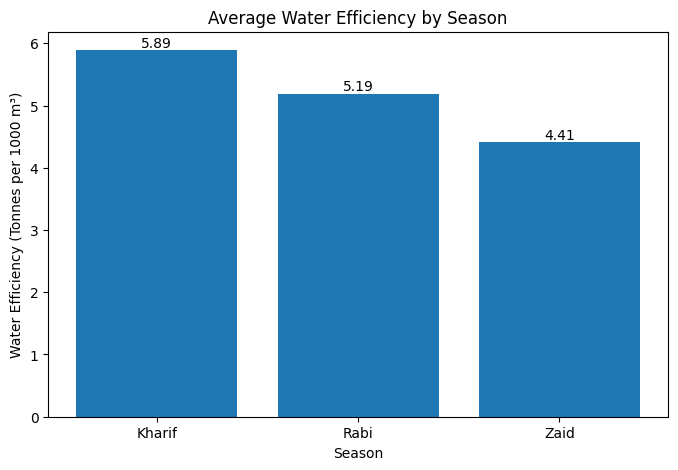

In [43]:
# Create a bar chart of average water efficiency by season
plt.figure(figsize=(8, 5))

plt.bar(
    season_water_efficiency.index,
    season_water_efficiency.values
)

plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')

# Display values on top of bars
for i, value in enumerate(season_water_efficiency.values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center')

plt.show()

# Interpretation

The analysis shows that Kharif has the highest average water efficiency at approximately 5.89 tonnes per 1000 m³, followed by Rabi at approximately 5.19 tonnes per 1000 m³. Zaid has the lowest average water efficiency at approximately 4.41 tonnes per 1000 m³.

An important observation is that Zaid has the highest average water usage but the lowest water efficiency among the three seasons. This indicates that higher water consumption does not necessarily result in more efficient agricultural output.

Kharif shows the highest water efficiency while also having the highest average yield and production. This suggests that Kharif performs better in terms of both agricultural productivity and water utilization efficiency in this dataset.

However, these observations describe associations in the dataset and do not establish that water usage directly causes changes in productivity.

# 19. Season-wise Disease and Pest Risk Analysis



Disease and pest risk can be an important factor in agricultural activities. In this analysis, the average disease and pest risk is compared across seasons to identify whether the level of risk varies with seasonal conditions.

Understanding this variation can help identify seasons that may require greater attention to crop protection and agricultural planning.

In [44]:
# Calculate average disease and pest risk for each season
season_risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean()

season_risk

,Disease_Pest_Risk_pct
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


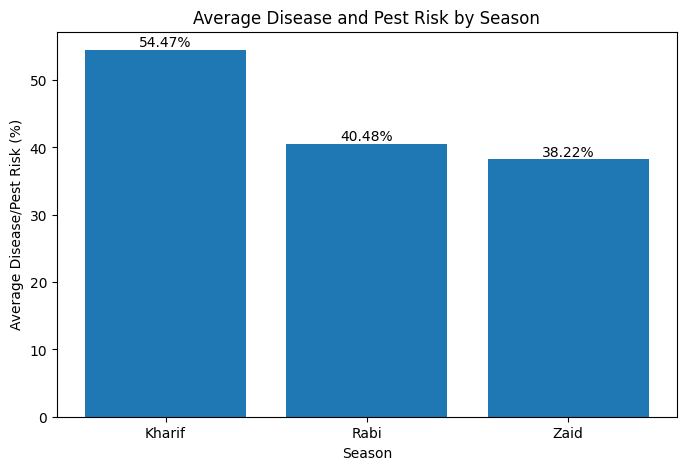

In [45]:
# Create a bar chart of average disease and pest risk by season
plt.figure(figsize=(8, 5))

plt.bar(season_risk.index, season_risk.values)

plt.title('Average Disease and Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Average Disease/Pest Risk (%)')

# Display values on top of bars
for i, value in enumerate(season_risk.values):
    plt.text(i, value + 0.5, f'{value:.2f}%', ha='center')

plt.show()

# Interpretation

The analysis shows that Kharif has the highest average disease and pest risk at approximately 54.47%, followed by Rabi at approximately 40.48%. Zaid has the lowest average risk at approximately 38.22%.

This indicates that disease and pest risk varies across seasons, with Kharif showing a considerably higher average risk than Rabi and Zaid.

Interestingly, Kharif also recorded the highest average yield, production, and profit in the previous analyses despite having the highest disease and pest risk. Therefore, higher disease and pest risk alone does not appear to explain the differences in agricultural performance observed across seasons.

Further analysis of farming practices, pesticide usage, seed quality, irrigation, and other factors would be required to better understand these differences.

# 20. Relationship Between Fertilizer Usage and Agricultural Yield

Fertilizer usage is an important farming practice that may be associated with agricultural productivity. In this analysis, fertilizer usage per hectare is compared with agricultural yield to investigate whether a relationship or pattern exists between the two variables.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

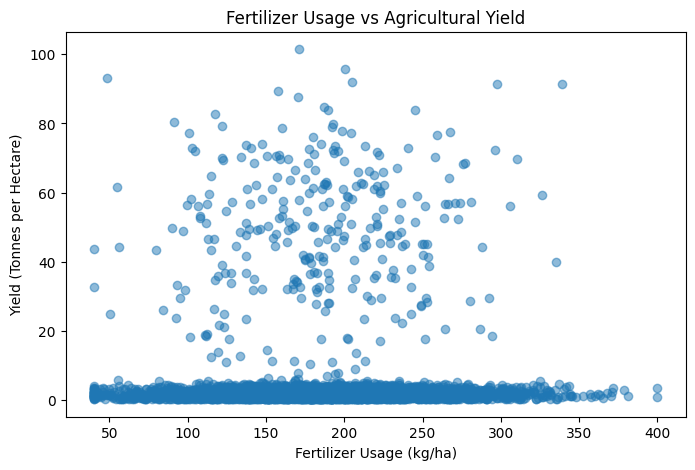

In [46]:
# Create a scatter plot of fertilizer usage and yield
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Fertilizer_kg_ha'],
    df['Yield_Tonnes_Ha'],
    alpha=0.5
)

plt.title('Fertilizer Usage vs Agricultural Yield')
plt.xlabel('Fertilizer Usage (kg/ha)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.show()

In [47]:
# Calculate the correlation between fertilizer usage and yield
fertilizer_yield_corr = df['Fertilizer_kg_ha'].corr(
    df['Yield_Tonnes_Ha']
)

print(
    "Correlation between Fertilizer Usage and Yield:",
    fertilizer_yield_corr
)

Correlation between Fertilizer Usage and Yield: 1.7712703696042472e-05


# Interpretation

The scatter plot shows considerable variation in agricultural yield across different levels of fertilizer usage. The observations do not form a clear linear pattern.

The correlation coefficient between fertilizer usage and agricultural yield is approximately 0.00002, which is essentially zero. This indicates that there is almost no linear association between fertilizer usage and yield in this dataset.

Therefore, fertilizer usage alone does not appear to explain the variation in agricultural yield. Other factors such as soil conditions, irrigation, seed quality, environmental conditions, and farming practices may also be associated with differences in yield.

It is important to note that correlation does not imply causation. This analysis only describes the observed linear relationship between fertilizer usage and yield in the available dataset.

# 21. Relationship Between Seed Quality and Agricultural Yield

Seed quality is an important factor in agricultural production. In this analysis, seed quality score is compared with agricultural yield to investigate whether better seed quality is associated with differences in yield.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

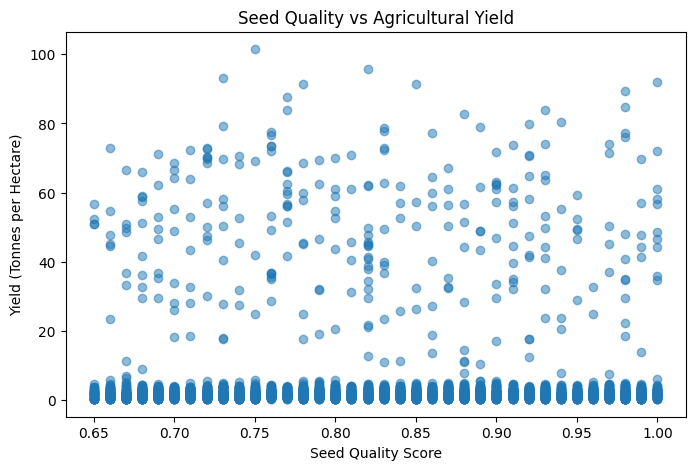

In [48]:
# Create a scatter plot of seed quality and yield
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Seed_Quality_Score'],
    df['Yield_Tonnes_Ha'],
    alpha=0.5
)

plt.title('Seed Quality vs Agricultural Yield')
plt.xlabel('Seed Quality Score')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.show()

In [49]:
# Calculate the correlation between seed quality and yield
seed_quality_yield_corr = df['Seed_Quality_Score'].corr(
    df['Yield_Tonnes_Ha']
)

print(
    "Correlation between Seed Quality and Yield:",
    seed_quality_yield_corr
)

Correlation between Seed Quality and Yield: -0.007208500583094007


# Interpretation

The scatter plot shows considerable variation in agricultural yield across different seed quality scores, and the observations do not form a clear linear pattern.

The correlation coefficient between seed quality score and agricultural yield is approximately -0.007, indicating an almost negligible negative linear relationship between the two variables.

Therefore, seed quality score alone does not appear to have a strong linear association with agricultural yield in this dataset. Other factors such as environmental conditions, soil properties, irrigation, fertilizer usage, and farming practices may also be associated with variations in yield.

It is important to note that correlation does not imply causation. This analysis only describes the observed linear relationship between seed quality and yield in the available dataset.

# 22. Irrigation Method and Agricultural Yield

Irrigation is an important farming practice that can influence agricultural productivity. The dataset contains different irrigation methods, so this analysis compares the average agricultural yield across irrigation methods.

This helps identify whether differences in average yield are observed across different irrigation practices.

In [50]:
# Calculate average yield for each irrigation method
irrigation_yield = df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean()

irrigation_yield

,Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.58
Flood,4.86
Rainfed,4.60
Sprinkler,5.16


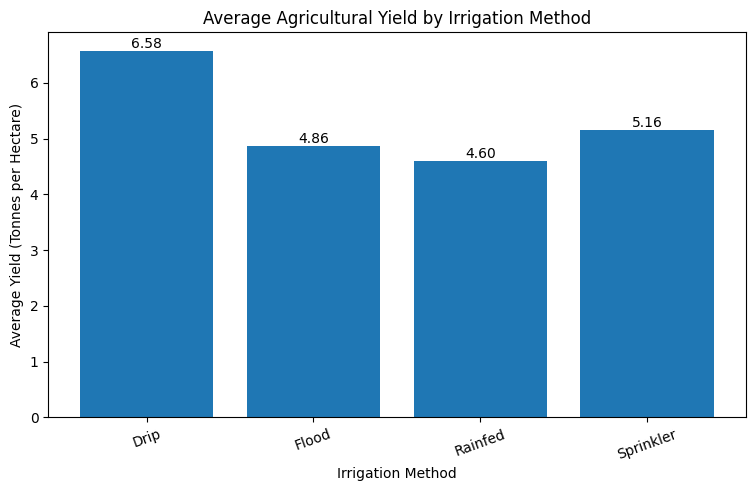

In [51]:
# Create a bar chart of average yield by irrigation method
plt.figure(figsize=(9, 5))

plt.bar(irrigation_yield.index, irrigation_yield.values)

plt.title('Average Agricultural Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes per Hectare)')

# Display values on top of bars
for i, value in enumerate(irrigation_yield.values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center')

plt.xticks(rotation=20)

plt.show()

# Interpretation

The analysis shows that farms using Drip irrigation have the highest average agricultural yield at approximately 6.58 tonnes per hectare. Sprinkler irrigation has an average yield of approximately 5.17 tonnes per hectare, followed by Flood irrigation at approximately 4.86 tonnes per hectare.

Rainfed farming has the lowest average yield at approximately 4.60 tonnes per hectare.

The results indicate that average agricultural yield differs across irrigation methods in this dataset. Drip irrigation is associated with the highest average yield, while Rainfed farming shows the lowest average yield.

However, these results describe an association and do not prove that the irrigation method alone causes higher or lower yield. Other factors such as soil conditions, crop type, season, environmental conditions, and farming practices may also contribute to these differences.

# 23. Crop-wise Average Yield Analysis

Different crops may have different productivity levels due to their characteristics and cultivation requirements. In this analysis, the average agricultural yield is compared across different crop types.

This helps identify which crops have higher or lower average yield in the available dataset.

In [52]:
# Calculate average yield for each crop
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean()

crop_yield

,Yield_Tonnes_Ha
Crop,
Chilli,1.54
Cotton,1.23
Groundnut,1.32
Maize,2.71
Pulses,0.92
Rice,2.43
Sugarcane,46.64
Wheat,2.11


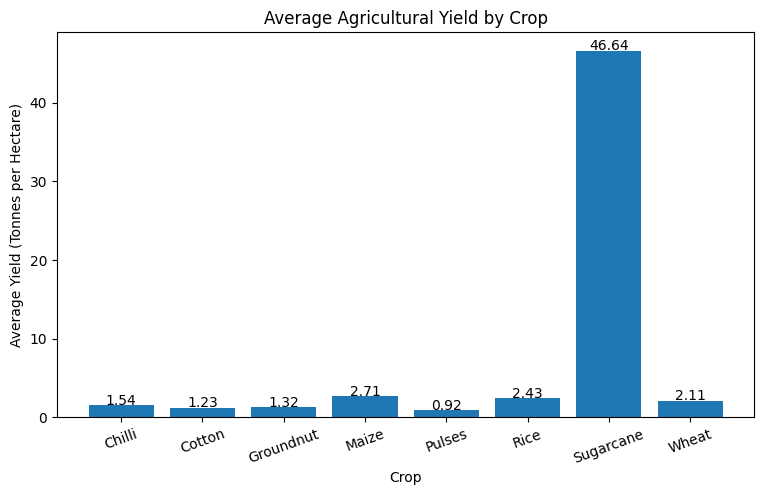

In [53]:
# Create a bar chart of average yield by crop
plt.figure(figsize=(9, 5))

plt.bar(crop_yield.index, crop_yield.values)

plt.title('Average Agricultural Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes per Hectare)')

# Display values on top of bars
for i, value in enumerate(crop_yield.values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center')

plt.xticks(rotation=20)

plt.show()

# Interpretation

The analysis shows substantial differences in average agricultural yield across different crops.

Sugarcane has the highest average yield at approximately 46.64 tonnes per hectare. Maize has the second-highest average yield at approximately 2.71 tonnes per hectare, followed by Rice at 2.43 tonnes per hectare and Wheat at 2.11 tonnes per hectare.

Among the remaining crops, Chilli has an average yield of approximately 1.54 tonnes per hectare, Groundnut 1.32 tonnes per hectare, and Cotton 1.23 tonnes per hectare. Pulses have the lowest average yield at approximately 0.92 tonnes per hectare.

The results indicate that crop type is associated with substantial differences in average yield in this dataset. Sugarcane shows a particularly high average yield compared with the other crops.

However, the yield values should be interpreted within the context of each crop because different crops can naturally have different production scales and characteristics.

# 24. Crop-wise Average Profit Analysis

Agricultural performance also includes economic outcomes. Different crops may generate different levels of profit because of differences in production, market prices, and costs.

In this analysis, the average profit is compared across different crops to identify differences in economic performance.

In [54]:
# Calculate average profit for each crop
crop_profit = df.groupby('Crop')['Profit_INR'].mean()

crop_profit

,Profit_INR
Crop,
Chilli,750878.34
Cotton,124546.92
Groundnut,44858.12
Maize,-83978.33
Pulses,-4238.05
Rice,-102213.50
Sugarcane,817187.99
Wheat,-123398.34


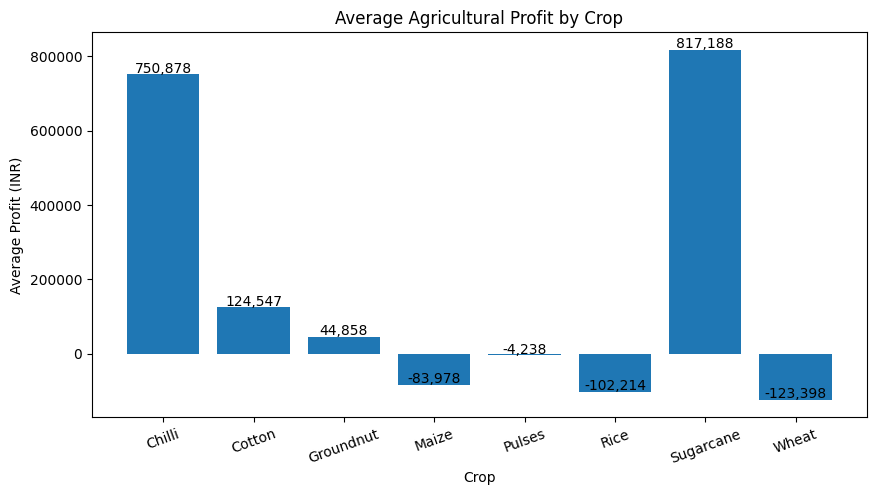

In [55]:
# Create a bar chart of average profit by crop
plt.figure(figsize=(10, 5))

plt.bar(crop_profit.index, crop_profit.values)

plt.title('Average Agricultural Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')

# Display values on top of bars
for i, value in enumerate(crop_profit.values):
    plt.text(i, value + 5000, f'{value:,.0f}', ha='center')

plt.xticks(rotation=20)

plt.show()

# Interpretation

The analysis shows substantial differences in average profit across different crops.

Sugarcane has the highest average profit at approximately INR 817,188, followed by Chilli at approximately INR 750,878. Cotton and Groundnut show positive average profits of approximately INR 124,547 and INR 44,858 respectively.

Pulses have a slightly negative average profit of approximately INR -4,238, while Maize, Rice, and Wheat show negative average profits of approximately INR -83,978, INR -102,214, and INR -123,398 respectively.

The results indicate that crop type is associated with considerable differences in economic performance in this dataset. Sugarcane shows both the highest average yield and the highest average profit among the crops analyzed.

However, profit depends on several factors such as production quantity, market price, and total cost. Therefore, crop type alone cannot be considered the sole reason for the observed differences in profit.

# 25. Crop-wise Average Cost and Revenue Analysis

Profit is determined by the difference between revenue and total cost. Therefore, comparing average revenue and average cost across crops helps explain the differences in profitability observed in the previous analysis.

In this analysis, the average total cost and average revenue are compared across different crops.

In [56]:
# Calculate average cost and revenue for each crop
crop_economic = df.groupby('Crop')[['Total_Cost_INR', 'Revenue_INR']].mean()

crop_economic

,Total_Cost_INR,Revenue_INR
Crop,,
Chilli,525898.89,1276777.23
Cotton,514876.17,639423.08
Groundnut,498077.38,542935.50
Maize,541046.32,457067.99
Pulses,532703.92,528465.87
Rice,525828.76,423615.26
Sugarcane,554792.13,1371980.11
Wheat,523503.22,400104.89


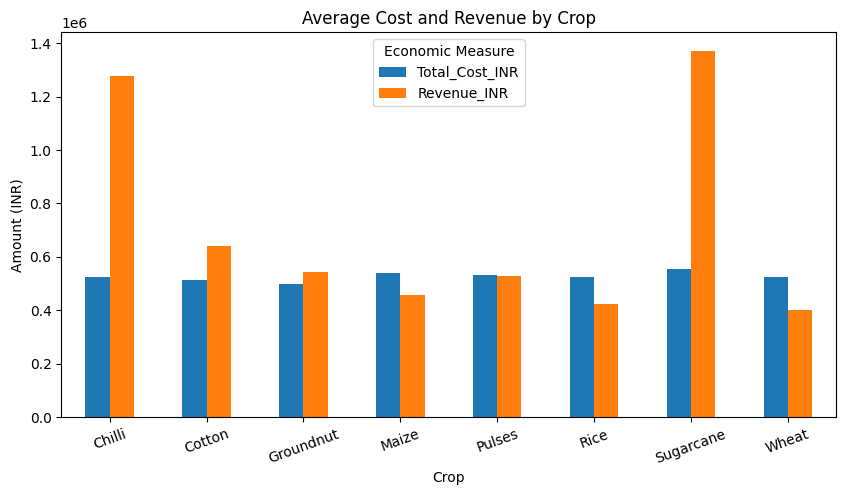

In [57]:
# Create a grouped bar chart for average cost and revenue
crop_economic.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Average Cost and Revenue by Crop')
plt.xlabel('Crop')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=20)
plt.legend(title='Economic Measure')

plt.show()

# Interpretation

The analysis shows clear differences between average cost and average revenue across crops.

Sugarcane has the highest average revenue at approximately INR 1,371,980, while its average total cost is approximately INR 554,792. This large difference between revenue and cost explains its highest average profit observed in the previous analysis.

Chilli also shows strong economic performance, with an average revenue of approximately INR 1,276,777 compared with an average cost of approximately INR 525,899.

Cotton and Groundnut also have average revenues higher than their average costs, resulting in positive average profits.

In contrast, Maize, Pulses, Rice, and Wheat have average revenues lower than their average total costs. This explains their negative average profits observed in the previous analysis.

Overall, the comparison of average cost and revenue helps explain why profitability differs across crops in the dataset.

# 26. Crop-wise Average Production Analysis

Production represents the total quantity of agricultural output produced by farms. Different crops may have different production levels due to differences in crop characteristics, cultivated area, yield, and farming conditions.

In this analysis, the average production is compared across different crops to identify differences in agricultural output.

In [58]:
# Calculate average production for each crop
crop_production = df.groupby('Crop')['Production_Tonnes'].mean()

crop_production

,Production_Tonnes
Crop,
Chilli,12.38
Cotton,9.40
Groundnut,9.66
Maize,21.78
Pulses,7.40
Rice,19.29
Sugarcane,392.41
Wheat,16.85


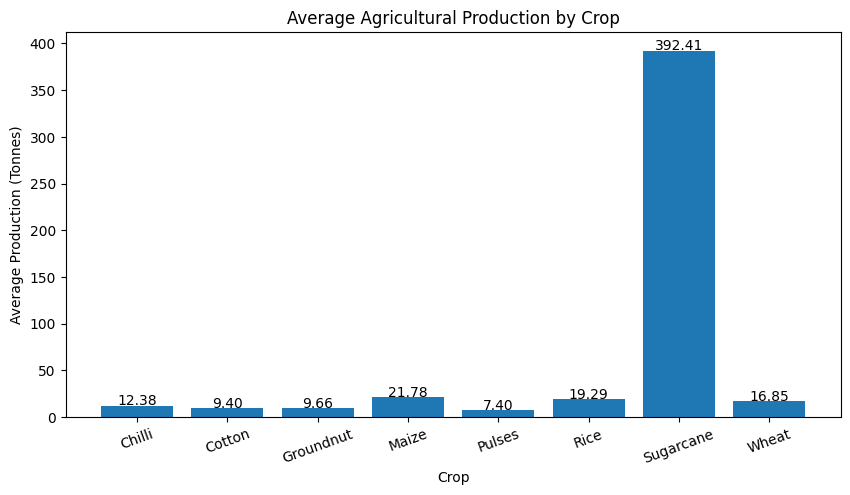

In [59]:
# Create a bar chart of average production by crop
plt.figure(figsize=(10, 5))

plt.bar(crop_production.index, crop_production.values)

plt.title('Average Agricultural Production by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Production (Tonnes)')

# Display values on top of bars
for i, value in enumerate(crop_production.values):
    plt.text(i, value + 0.5, f'{value:.2f}', ha='center')

plt.xticks(rotation=20)

plt.show()

# Interpretation

The analysis shows considerable differences in average production across different crops.

Sugarcane has the highest average production at approximately 392.41 tonnes, followed by Maize at approximately 21.78 tonnes and Rice at approximately 19.29 tonnes.

Wheat has an average production of approximately 16.85 tonnes, followed by Chilli at 12.38 tonnes, Groundnut at 9.66 tonnes, and Cotton at 9.40 tonnes. Pulses have the lowest average production at approximately 7.40 tonnes.

The results indicate that crop type is associated with substantial differences in average production in this dataset. Sugarcane shows a particularly high average production compared with the other crops.

The high production of Sugarcane is also consistent with its high average yield and high average profit observed in the previous analyses.

# 27. Relationship Between Production and Agricultural Yield

Production and yield are both important measures of agricultural performance. Yield represents productivity per hectare, while production represents the total quantity produced.

In this analysis, production is compared with agricultural yield to investigate whether a linear relationship exists between the two variables.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

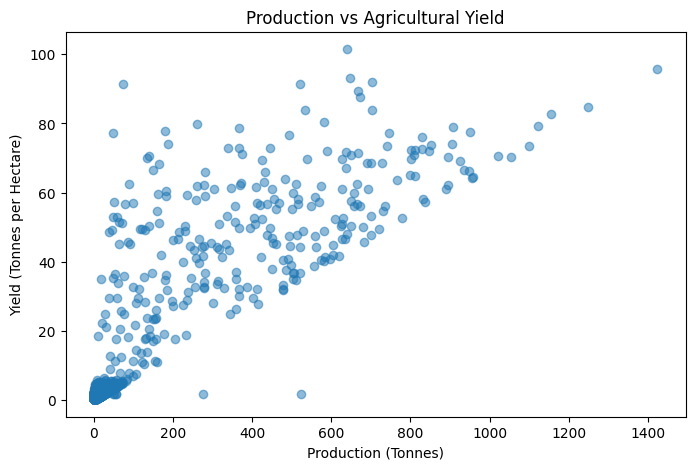

In [60]:
# Create a scatter plot of production and yield
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Production_Tonnes'],
    df['Yield_Tonnes_Ha'],
    alpha=0.5
)

plt.title('Production vs Agricultural Yield')
plt.xlabel('Production (Tonnes)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.show()

In [61]:
# Calculate the correlation between production and yield
production_yield_corr = df['Production_Tonnes'].corr(
    df['Yield_Tonnes_Ha']
)

print(
    "Correlation between Production and Yield:",
    production_yield_corr
)

Correlation between Production and Yield: 0.8828128675727296


# Interpretation

The scatter plot shows a clear positive relationship between production and agricultural yield. As production increases, yield generally tends to increase as well.

The correlation coefficient between production and yield is approximately 0.883, indicating a strong positive linear association between the two variables.

This suggests that farms with higher production levels tend to have higher yield values in the dataset. However, correlation does not imply causation, and other factors such as farm area, crop type, season, irrigation, and environmental conditions may also contribute to this relationship.

# 28. Relationship Between Farm Area and Agricultural Production

Farm area is an important factor that may influence the total quantity of agricultural production. In this analysis, farm area is compared with total production to investigate whether a relationship exists between the two variables.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

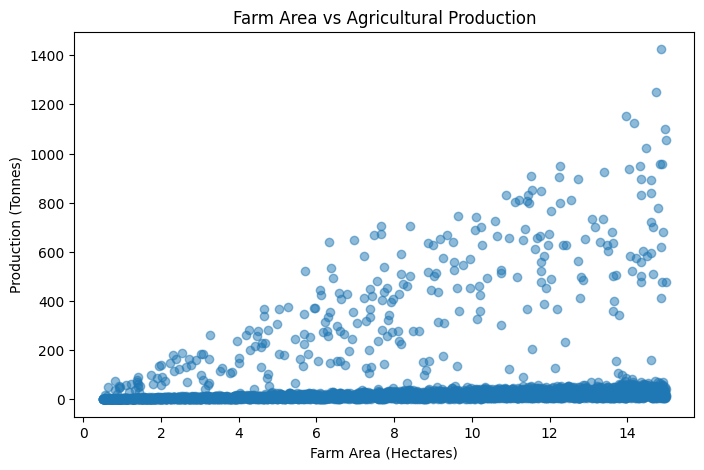

In [62]:
# Create a scatter plot of farm area and production
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Farm_Area_Hectares'],
    df['Production_Tonnes'],
    alpha=0.5
)

plt.title('Farm Area vs Agricultural Production')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Production (Tonnes)')

plt.show()

In [63]:
# Calculate the correlation between farm area and production
area_production_corr = df['Farm_Area_Hectares'].corr(
    df['Production_Tonnes']
)

print(
    "Correlation between Farm Area and Production:",
    area_production_corr
)

Correlation between Farm Area and Production: 0.197841674306544


# Interpretation

The scatter plot shows a generally positive pattern between farm area and agricultural production, although the observations are widely scattered.

The correlation coefficient between farm area and agricultural production is approximately 0.198, indicating a weak positive linear relationship between the two variables.

This suggests that larger farm areas tend to be associated with somewhat higher production, but the relationship is not strong. Therefore, farm area alone does not fully explain the variation in agricultural production.

Other factors such as crop type, yield, season, irrigation, environmental conditions, and farming practices may also contribute to differences in production.

# 29. Season-wise Average Revenue Analysis

Revenue represents the income generated from agricultural production. Since revenue can vary across seasons due to differences in production and market conditions, this analysis compares the average revenue across different seasons.

The purpose is to identify seasonal differences in agricultural revenue.

In [64]:
# Calculate average revenue for each season
season_revenue = df.groupby('Season')['Revenue_INR'].mean()

season_revenue

,Revenue_INR
Season,
Kharif,710719.06
Rabi,601526.05
Zaid,519171.90


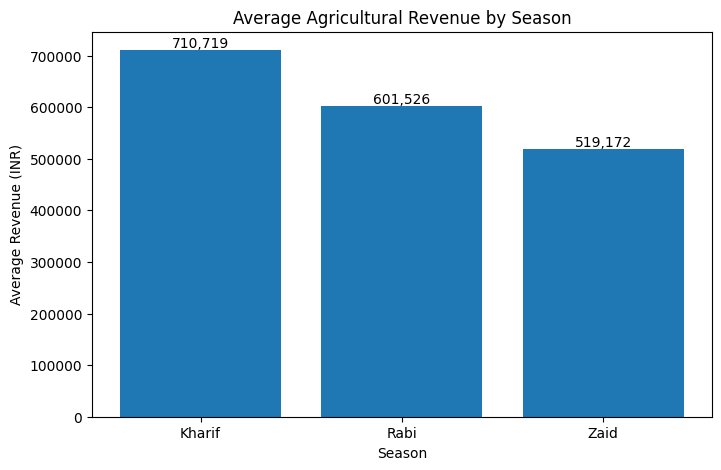

In [65]:
# Create a bar chart of average revenue by season
plt.figure(figsize=(8, 5))

plt.bar(season_revenue.index, season_revenue.values)

plt.title('Average Agricultural Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')

# Display values on top of bars
for i, value in enumerate(season_revenue.values):
    plt.text(i, value + 5000, f'{value:,.0f}', ha='center')

plt.show()

# Interpretation

The analysis shows that average agricultural revenue varies across seasons.

Kharif has the highest average revenue at approximately INR 710,719, followed by Rabi at approximately INR 601,526. Zaid has the lowest average revenue at approximately INR 519,172.

The results indicate that Kharif generates the highest average revenue among the three seasons, while Zaid generates the lowest.

This pattern is consistent with the previous profit analysis, where Kharif also showed the highest average profit. However, revenue alone does not determine profitability because total cost must also be considered.

# 30. Season-wise Average Market Price Analysis

Market price is an important economic factor that can influence agricultural revenue. In this analysis, the average market price per tonne is compared across different seasons.

The purpose is to identify seasonal differences in market prices and understand whether market price patterns may be associated with differences in agricultural revenue.

In [66]:
# Calculate average market price for each season
season_market_price = df.groupby('Season')['Market_Price_INR_Tonne'].mean()

season_market_price

,Market_Price_INR_Tonne
Season,
Kharif,44850.91
Rabi,44747.97
Zaid,44212.03


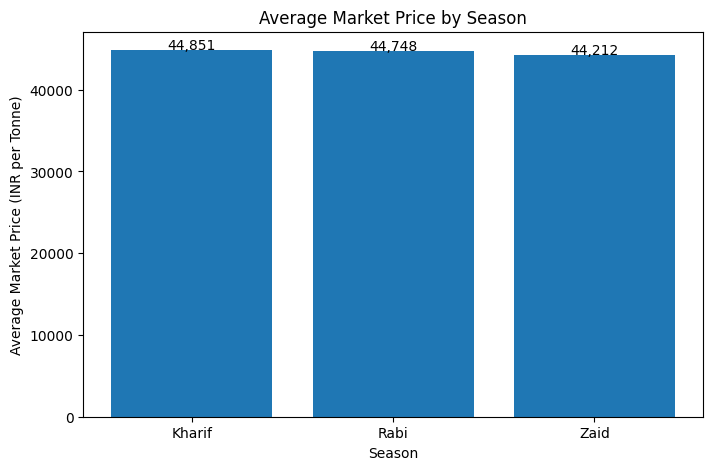

In [67]:
# Create a bar chart of average market price by season
plt.figure(figsize=(8, 5))

plt.bar(season_market_price.index, season_market_price.values)

plt.title('Average Market Price by Season')
plt.xlabel('Season')
plt.ylabel('Average Market Price (INR per Tonne)')

# Display values on top of bars
for i, value in enumerate(season_market_price.values):
    plt.text(i, value + 100, f'{value:,.0f}', ha='center')

plt.show()

# Interpretation

The analysis shows that the average market price per tonne is relatively similar across all three seasons.

Kharif has the highest average market price at approximately INR 44,851 per tonne, followed by Rabi at approximately INR 44,748 per tonne. Zaid has the lowest average market price at approximately INR 44,212 per tonne.

The difference between the highest and lowest seasonal average market price is relatively small. Therefore, seasonal variation in market price appears to be limited in this dataset.

Although Kharif has the highest average revenue, the small difference in average market prices suggests that factors such as production quantity and yield may contribute more significantly to the seasonal differences in revenue.

# 31. Relationship Between Market Price and Agricultural Revenue

Market price is an important component of agricultural revenue. In this analysis, market price per tonne is compared with total agricultural revenue to examine whether a relationship exists between the two variables.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

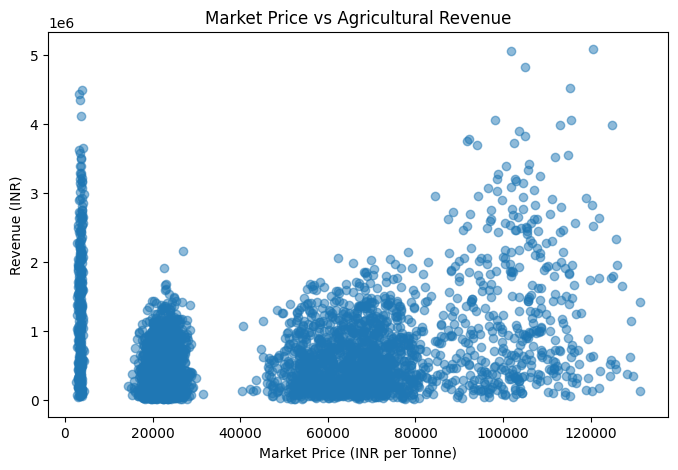

In [68]:
# Create a scatter plot of market price and revenue
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Market_Price_INR_Tonne'],
    df['Revenue_INR'],
    alpha=0.5
)

plt.title('Market Price vs Agricultural Revenue')
plt.xlabel('Market Price (INR per Tonne)')
plt.ylabel('Revenue (INR)')

plt.show()

In [69]:
# Calculate the correlation between market price and revenue
market_price_revenue_corr = df['Market_Price_INR_Tonne'].corr(
    df['Revenue_INR']
)

print(
    "Correlation between Market Price and Revenue:",
    market_price_revenue_corr
)

Correlation between Market Price and Revenue: 0.18233814082862906


# Interpretation

The correlation between market price and agricultural revenue is approximately 0.182, indicating a weak positive relationship between the two variables. This means that higher market prices are generally associated with slightly higher agricultural revenue, but the relationship is not strong. Therefore, market price alone does not explain most of the variation in agricultural revenue.

# 32. Relationship Between Total Cost and Agricultural Profit

Total cost is an important factor affecting agricultural profitability. In this analysis, total cost is compared with agricultural profit to investigate whether a relationship exists between the two variables.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

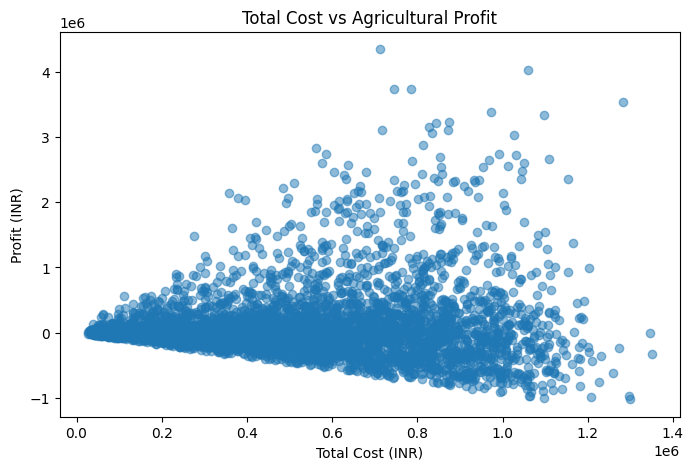

In [70]:
# Create a scatter plot of total cost and profit
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Total_Cost_INR'],
    df['Profit_INR'],
    alpha=0.5
)

plt.title('Total Cost vs Agricultural Profit')
plt.xlabel('Total Cost (INR)')
plt.ylabel('Profit (INR)')

plt.show()

In [71]:
# Calculate the correlation between total cost and profit
cost_profit_corr = df['Total_Cost_INR'].corr(
    df['Profit_INR']
)

print(
    "Correlation between Total Cost and Profit:",
    cost_profit_corr
)

Correlation between Total Cost and Profit: 0.06835598155697735


# Interpretation

The correlation between total cost and agricultural profit is approximately 0.068. This indicates a very weak positive relationship between total cost and profit. Therefore, total cost alone does not strongly explain the variation in agricultural profit.

# 33. Relationship Between Production and Agricultural Revenue

Production is an important factor that may influence agricultural revenue. In this analysis, total agricultural production is compared with revenue to investigate whether a relationship exists between the two variables.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

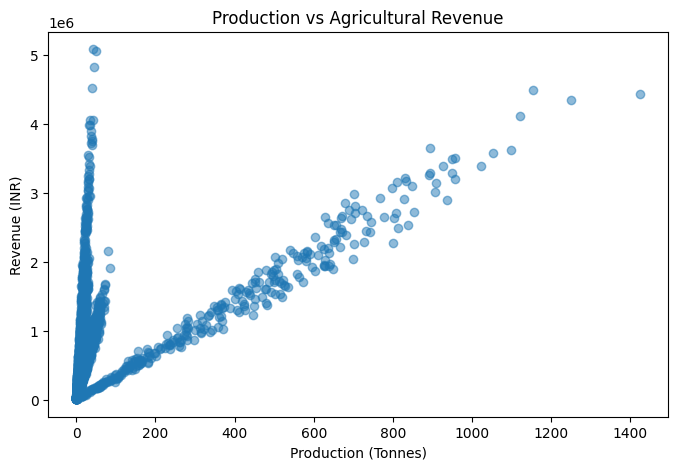

In [72]:
# Create a scatter plot of production and revenue
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Production_Tonnes'],
    df['Revenue_INR'],
    alpha=0.5
)

plt.title('Production vs Agricultural Revenue')
plt.xlabel('Production (Tonnes)')
plt.ylabel('Revenue (INR)')

plt.show()

In [73]:
# Calculate the correlation between production and revenue
production_revenue_corr = df['Production_Tonnes'].corr(
    df['Revenue_INR']
)

print(
    "Correlation between Production and Revenue:",
    production_revenue_corr
)

Correlation between Production and Revenue: 0.563505034256987


# Interpretation

The correlation between production and agricultural revenue is approximately 0.564. This indicates a moderate positive relationship between the two variables. This means that higher agricultural production is generally associated with higher revenue. However, production alone does not completely explain the variation in agricultural revenue.

# 34. Relationship Between Farm Area and Agricultural Yield

Farm area may influence agricultural productivity by determining the amount of land available for cultivation. In this analysis, farm area is compared with agricultural yield to investigate whether a relationship exists between the two variables.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

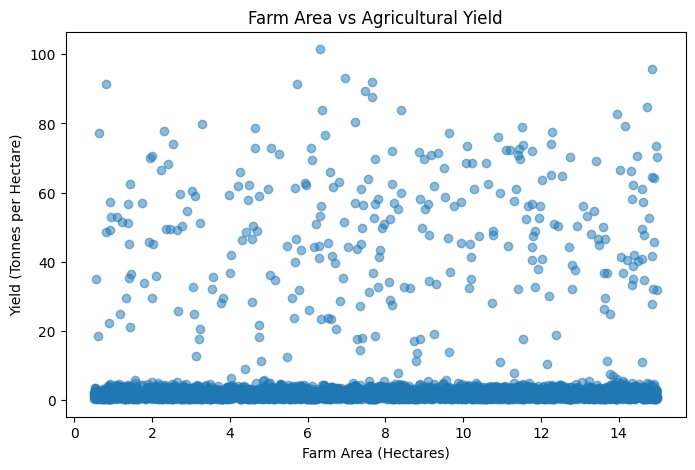

In [74]:
# Create a scatter plot of farm area and yield
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Farm_Area_Hectares'],
    df['Yield_Tonnes_Ha'],
    alpha=0.5
)

plt.title('Farm Area vs Agricultural Yield')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.show()

In [75]:
# Calculate the correlation between farm area and yield
area_yield_corr = df['Farm_Area_Hectares'].corr(
    df['Yield_Tonnes_Ha']
)

print(
    "Correlation between Farm Area and Yield:",
    area_yield_corr
)

Correlation between Farm Area and Yield: 0.030203195606722025


# Interpretation

The correlation between farm area and agricultural yield is approximately 0.030. This indicates a very weak positive relationship between the two variables. Therefore, farm area alone does not have a strong linear relationship with agricultural yield in this dataset.

# 35. Relationship Between Farm Area and Agricultural Profit

Farm area may influence agricultural profitability through its effect on production and operating costs. In this analysis, farm area is compared with agricultural profit to investigate whether a relationship exists between the two variables.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

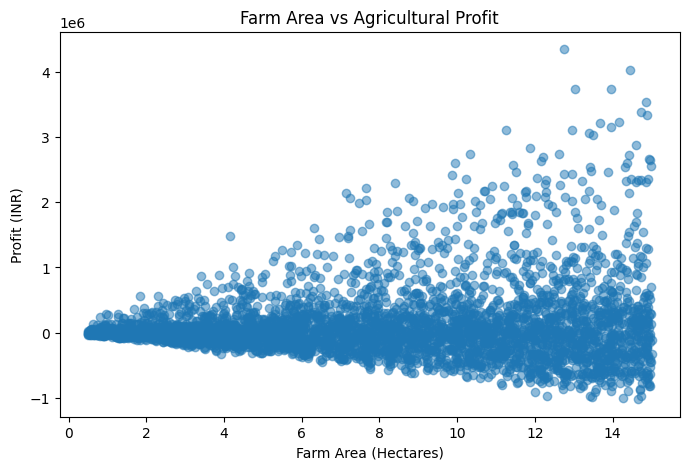

In [76]:
# Create a scatter plot of farm area and profit
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Farm_Area_Hectares'],
    df['Profit_INR'],
    alpha=0.5
)

plt.title('Farm Area vs Agricultural Profit')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Profit (INR)')

plt.show()

In [77]:
# Calculate the correlation between farm area and profit
area_profit_corr = df['Farm_Area_Hectares'].corr(
    df['Profit_INR']
)

print(
    "Correlation between Farm Area and Profit:",
    area_profit_corr
)

Correlation between Farm Area and Profit: 0.11524097068022542


# Interpretation

The correlation between farm area and agricultural profit is approximately 0.115. This indicates a very weak positive relationship between the two variables. Therefore, farm area alone does not have a strong linear relationship with agricultural profit in this dataset.

# 36. Relationship Between Water Usage and Agricultural Production

Water usage is an important agricultural resource that may influence total production. In this analysis, water usage is compared with agricultural production to investigate whether a relationship exists between the two variables.

A scatter plot and correlation coefficient are used to examine the strength and direction of the relationship.

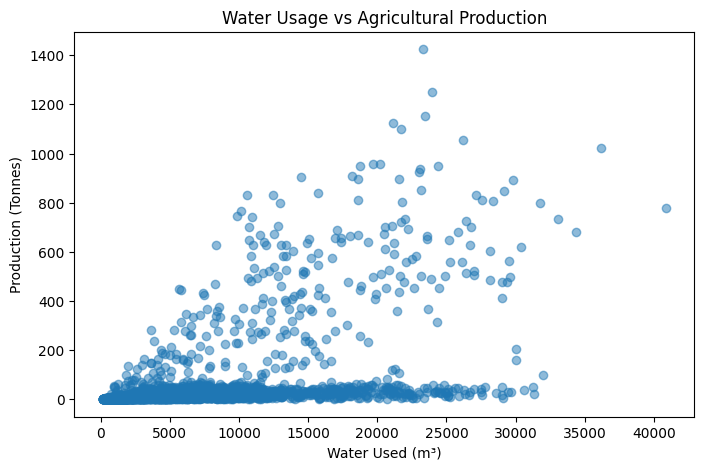

In [78]:
# Create a scatter plot of water usage and production
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Water_Used_m3'],
    df['Production_Tonnes'],
    alpha=0.5
)

plt.title('Water Usage vs Agricultural Production')
plt.xlabel('Water Used (m³)')
plt.ylabel('Production (Tonnes)')

plt.show()

In [79]:
# Calculate the correlation between water usage and production
water_production_corr = df['Water_Used_m3'].corr(
    df['Production_Tonnes']
)

print(
    "Correlation between Water Usage and Production:",
    water_production_corr
)

Correlation between Water Usage and Production: 0.5155568672701039


# Interpretation

The correlation between water usage and agricultural production is approximately 0.516. This indicates a moderate positive relationship between the two variables. This means that higher water usage is generally associated with higher agricultural production. However, water usage alone does not completely explain the variation in agricultural production.

# 37. State-wise Agricultural Performance Analysis

Agricultural performance may vary across different states due to differences in climate, land availability, farming practices, irrigation, and resource utilization.

In this analysis, the average yield, production, revenue, and profit are compared across states to identify regional differences in agricultural performance.

The purpose is to identify states with relatively higher or lower agricultural and economic performance in the available dataset.

In [80]:
# Calculate state-wise average agricultural performance

state_analysis = df.groupby('State')[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR'
]].mean()

state_analysis


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
State,,,,
Andhra Pradesh,4.63,36.91,606663.66,73453.53
Gujarat,5.66,48.33,654692.86,117568.24
Karnataka,5.69,47.73,653426.18,119422.34
Madhya Pradesh,4.99,37.56,597558.36,86840.76
Maharashtra,5.02,43.98,650032.67,135428.86
Punjab,6.12,52.23,686225.70,136025.64
Tamil Nadu,4.88,40.84,629093.42,117744.75
Telangana,5.04,39.25,628784.53,108829.62


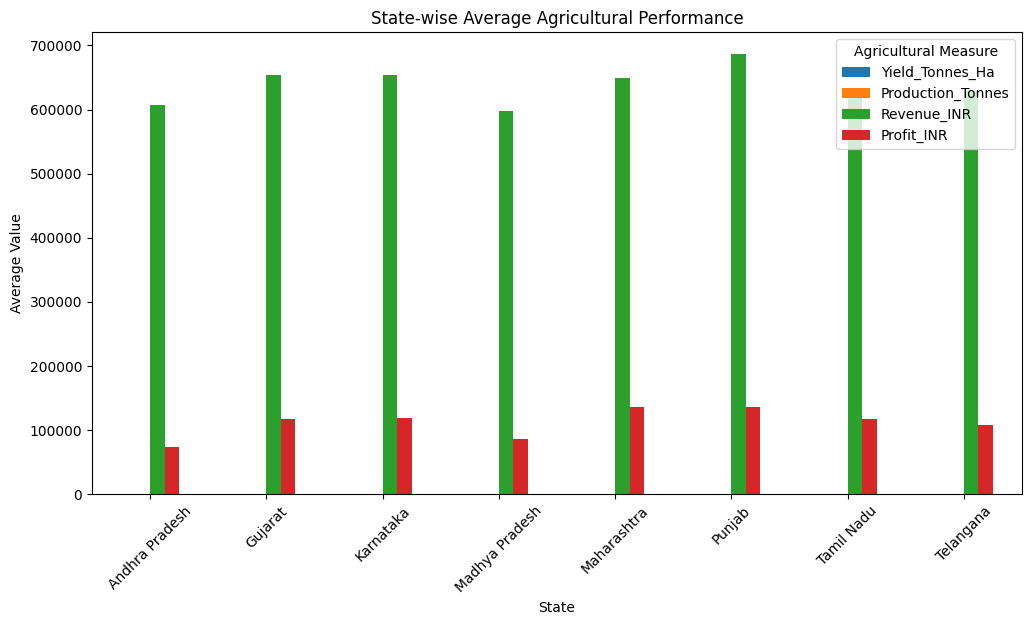

In [81]:
# Create a grouped bar chart for state-wise performance

state_analysis.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('State-wise Average Agricultural Performance')
plt.xlabel('State')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(title='Agricultural Measure')

plt.show()

# 38. District-wise Agricultural Performance Analysis

Agricultural performance can also vary significantly between districts within a state.

In this analysis, the average yield, production, revenue, and profit are compared across districts to identify districts with relatively higher or lower agricultural performance.

This analysis provides a more detailed regional view than the state-wise analysis.

In [82]:
# Calculate district-wise average agricultural performance

district_analysis = df.groupby('District')[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Profit_INR'
]].mean()

district_analysis

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
District,,,,
Erode,4.18,37.77,630542.70,102079.57
Guntur,5.47,44.62,635094.22,116411.42
Indore,4.88,38.56,630401.75,90421.34
Krishna,4.85,40.52,600329.53,78240.90
Ludhiana,5.80,45.16,621442.69,87590.83
Nalgonda,5.80,47.54,651104.56,131125.84
Nashik,4.86,36.74,614387.90,94910.17
Raichur,4.94,39.28,637352.42,125172.70
Rajkot,6.02,54.83,648998.32,119463.28


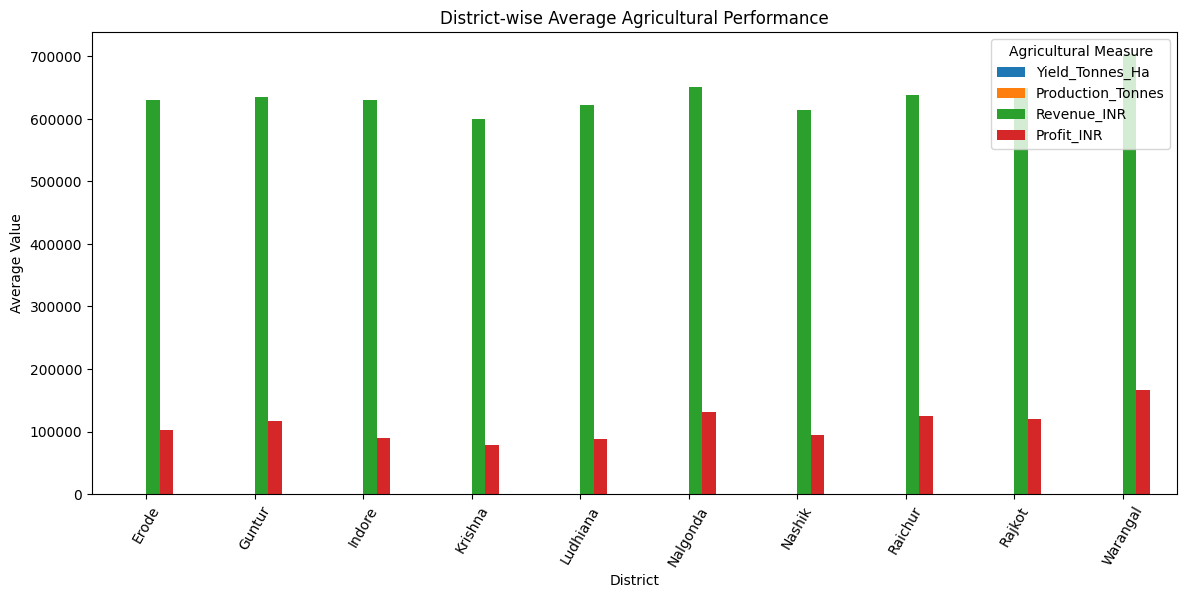

In [83]:
district_analysis.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title('District-wise Average Agricultural Performance')
plt.xlabel('District')
plt.ylabel('Average Value')
plt.xticks(rotation=60)
plt.legend(title='Agricultural Measure')

plt.show()

# Interpretation

The district-wise bar chart makes regional differences easier to identify. Districts with higher bars for yield, production, revenue, or profit demonstrate relatively stronger performance for the respective measure.

# 39. Overall Key Findings

The overall analysis provides insights into agricultural productivity, production, resource utilization, environmental conditions, and economic performance.

The major findings are summarized based on seasonal, crop-wise, environmental, resource, and economic analyses conducted in the dataset.

In [84]:
# Identify important overall rankings

print("Highest Average Yield Crop:")
print(crop_yield.idxmax(), "->", round(crop_yield.max(), 2))

print("\nHighest Average Profit Crop:")
print(crop_profit.idxmax(), "->", round(crop_profit.max(), 2))

print("\nLowest Average Profit Crop:")
print(crop_profit.idxmin(), "->", round(crop_profit.min(), 2))

print("\nHighest Average Production Crop:")
print(crop_production.idxmax(), "->", round(crop_production.max(), 2))

print("\nHighest Average Revenue Season:")
print(season_revenue.idxmax(), "->", round(season_revenue.max(), 2))

print("\nHighest Average Profit Season:")
print(season_profit.idxmax(), "->", round(season_profit.max(), 2))

Highest Average Yield Crop:
Sugarcane -> 46.64

Highest Average Profit Crop:
Sugarcane -> 817187.99

Lowest Average Profit Crop:
Wheat -> -123398.34

Highest Average Production Crop:
Sugarcane -> 392.41

Highest Average Revenue Season:
Kharif -> 710719.06

Highest Average Profit Season:
Kharif -> 178914.65


# Interpretation

The overall analysis provides several important insights into agricultural productivity, production, resource utilization, and economic performance.

**Crop-wise performance:** Sugarcane has the highest average agricultural yield of approximately **46.64 tonnes per hectare**, making it the most productive crop in the dataset. It also records the highest average production of approximately **392.41 tonnes** and the highest average profit of around **₹817,188**. Chilli is another highly profitable crop, with an average profit of approximately **₹750,878**.

**Negative profitability:** Wheat, Rice, Maize, and Pulses show negative average profits. This indicates that, on average, the revenue generated by these crops is lower than their associated costs in the available dataset. These crops may therefore require further analysis of production costs, market prices, and resource utilization.

**Season-wise performance:** Kharif has the highest average revenue of approximately **₹710,719**, followed by Rabi at approximately ₹601,526 and Zaid at approximately **₹519,172**. Kharif also shows the highest water-use efficiency at approximately **5.89 tonnes per 1000 m³**, while Zaid has the lowest at approximately **4.41 tonnes per 1000 m³**.

**Disease and pest risk:** Kharif has the highest average disease and pest risk at approximately **54.47%**, followed by Rabi at 40.**48%** and Zaid at **38.22%**. This suggests that Kharif may require greater attention to crop protection and pest management.

**Environmental factors:** Rainfall, temperature, and humidity show very weak linear relationships with agricultural yield. The correlation values are approximately **0.031 for rainfall, 0.010 for temperature, and 0.012 for humidity**. Therefore, these individual environmental variables do not show a strong linear association with yield in the available dataset.

**Fertilizer and seed quality:** Fertilizer usage has an almost zero correlation with yield, with a value of approximately **0.00002**. Seed quality also shows a very weak negative correlation with yield of approximately **-0.0072**. These results indicate that neither variable has a meaningful linear relationship with yield in this dataset.

**Production and yield:** Production has a strong positive correlation with agricultural yield of approximately **0.883**. This is one of the strongest relationships identified in the analysis, indicating that higher production is generally associated with higher agricultural yield.

**Water usage and production:** Water usage has a moderate positive correlation with production of approximately **0.516**. This indicates that higher water usage is generally associated with higher production, although water usage alone does not fully explain differences in production.

**Production and revenue:** Production has a moderate positive correlation with revenue of approximately **0.564**, suggesting that higher agricultural production generally tends to be associated with higher revenue.

**Market price and revenue:** Market price has a weak positive correlation with revenue of approximately **0.182**. This suggests that market price alone does not strongly explain variations in total agricultural revenue.

**Farm area:** Farm area has a weak relationship with both profit and yield. The correlation between farm area and profit is approximately **0.115**, while the correlation between farm area and yield is approximately **0.030**. Therefore, larger farm area alone does not strongly determine profitability or productivity.

**Irrigation methods:** The average yield differs across irrigation methods. Drip irrigation has the highest average yield at approximately **6.58 tonnes per hectare**, followed by Sprinkler at **5.16**, Flood at **4.86**, and Rainfed at **4.60** tonnes per hectare. This suggests that irrigation method may be an important factor to consider when evaluating agricultural productivity.

Overall, the analysis shows that agricultural performance varies across crops, seasons, irrigation methods, and economic conditions. The strongest relationship observed is between production and yield, while several environmental, input, and farm-size variables show very weak linear relationships with yield or profit. These findings indicate that agricultural performance is influenced by multiple factors rather than a single variable.

# 40. Final Conclusion

The agricultural analysis provides a comprehensive overview of productivity, production, resource utilization, environmental conditions, and economic performance.

The results show considerable differences across seasons and crops. Kharif demonstrates strong overall economic performance, while crop-wise analysis shows that Sugarcane has the highest average yield, production, and profit in the available dataset.

Several crops show negative average profit, indicating that their economic performance is weaker compared with more profitable crops.

The correlation analysis shows a strong positive relationship between production and agricultural yield. Production and water usage also show a moderate positive relationship, while production and revenue have a moderate positive relationship.

In contrast, market price and revenue, farm area and profit, and farm area and yield show weak relationships. Environmental variables also show very weak linear relationships with yield in the available analysis.

Overall, the results suggest that agricultural performance depends on multiple factors, and no single variable is sufficient to explain all differences in productivity and profitability.

# 41. Recommendations and Insights

Based on the analysis, the following recommendations can be considered:


1. High-performing crops such as Sugarcane and Chilli should be evaluated for suitable expansion where economic and resource conditions permit.

2. Crops showing negative average profit should be reviewed carefully with respect to production cost, revenue, market price, and resource requirements.

3. Kharif season shows strong economic performance but also requires attention to disease and pest management.

4. Water efficiency should be considered along with total water consumption when planning agricultural activities.

5. Since production has a strong positive relationship with yield, improving productive agricultural practices may help improve overall output.

6. Environmental variables such as rainfall, temperature, and humidity show very weak linear relationships with yield in this dataset. Therefore, agricultural decisions should not be based on a single environmental variable alone.

7. State-wise and district-wise performance should be used to identify regions with better productivity and profitability and to support region-specific agricultural planning.

8. Further analysis using additional variables and advanced statistical or machine learning techniques may help identify non-linear relationships that simple correlation analysis may not capture.